<a href="https://colab.research.google.com/github/surajjeoor/Mathematical_brain/blob/main/House_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#importing csv data as a pandas dataframe
pd_train=pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv')
pd_test=pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/test.csv')


In [3]:
pd_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
#quick diagnostics
print("======================================== Quick Diagnostics ==========================================")
print(f"The shape of the train data is {pd_train.shape}")
print(f"\n\n The shape of the test data is {pd_test.shape}")
print(f"\n\n Total Null values in the train data is {pd_train.isnull().sum()}")
print(f"\n\n Number of duplicate values in train data: {pd_train.duplicated().sum()}")
print(f"\n\n Total Null values in the test data is {pd_test.isnull().sum()}")
print(f"\n\n Number of duplicate values in test data: {pd_test.duplicated().sum()}")
print(f"====================================================================================================")
print(f"\t\t\t TOTAL NAN VALUES \t\t\t")
print(f"====================================================================================================")
print(f"\n\n Total Null values in the train data is {pd_train.isna().sum()}")
print(f"\n\n Total Null values in the test data is {pd_test.isna().sum()}")

======================================== Quick Diagnostics ==========================================
The shape of the train data is (1460, 81)


 The shape of the test data is (1459, 80)


 Total Null values in the train data is Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


 Number of duplicate values in train data: 0


 Total Null values in the test data is Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


 Number of duplicate values in test data: 0
			 TOTAL NAN VALUES 			


 Total Null values in the train data is Id                 0
MSSubClass         0
MSZoning       

In [5]:
pd_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
pd_train.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
pd_train.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [8]:
pd_train = pd_train.drop(['PoolQC', 'MiscFeature', 'Alley', 'Utilities', 'Street'], axis=1)
pd_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,...,0,0,0,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,...,0,0,0,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,...,0,0,0,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,...,0,0,0,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,...,0,0,0,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,...,0,0,0,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,...,0,0,0,MnPrv,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,...,0,0,0,GdPrv,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,...,0,0,0,NaN,0,4,2010,WD,Normal,142125


In [9]:
pd_train[['Fence','FireplaceQu','GarageType','GarageQual','GarageCond','GarageFinish','BsmtQual','BsmtCond','BsmtExposure']]

,Fence,FireplaceQu,GarageType,GarageQual,GarageCond,GarageFinish,BsmtQual,BsmtCond,BsmtExposure
0,NaN,NaN,Attchd,TA,TA,RFn,Gd,TA,No
1,NaN,TA,Attchd,TA,TA,RFn,Gd,TA,Gd
2,NaN,TA,Attchd,TA,TA,RFn,Gd,TA,Mn
3,NaN,Gd,Detchd,TA,TA,Unf,TA,Gd,No
4,NaN,TA,Attchd,TA,TA,RFn,Gd,TA,Av
...,...,...,...,...,...,...,...,...,...
1455,NaN,TA,Attchd,TA,TA,RFn,Gd,TA,No
1456,MnPrv,TA,Attchd,TA,TA,Unf,Gd,TA,No
1457,GdPrv,Gd,Attchd,TA,TA,RFn,TA,Gd,No
1458,NaN,NaN,Attchd,TA,TA,Unf,TA,TA,Mn


In [10]:
qual_map={'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5}
pd_train['FireplaceQu']=pd_train['FireplaceQu'].fillna('None').map(qual_map)
pd_train['FireplaceQu']

,FireplaceQu
0,0
1,3
2,3
3,4
4,3
...,...
1455,3
1456,3
1457,4
1458,0


In [11]:
pd_train['FireplaceQu'].fillna('None').unique()

array([0, 3, 4, 2, 5, 1])

In [12]:
# Count NaNs AFTER mapping — if this is > 0, you missed a category
pd_train['FireplaceQu'].isna().sum()

np.int64(0)

In [13]:
pd_train[['BsmtQual','BsmtCond']]=pd_train[['BsmtQual','BsmtCond']].fillna('None').replace(qual_map)
pd_train[['BsmtQual','BsmtCond']]

/tmp/ipykernel_419/1879487620.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pd_train[['BsmtQual','BsmtCond']]=pd_train[['BsmtQual','BsmtCond']].fillna('None').replace(qual_map)


,BsmtQual,BsmtCond
0,4,3
1,4,3
2,4,3
3,3,4
4,4,3
...,...,...
1455,4,3
1456,4,3
1457,3,4
1458,3,3


In [14]:
pd_train[['GarageQual','GarageCond']]=pd_train[['GarageQual','GarageCond']].fillna('None').replace(qual_map)
pd_train[['GarageQual','GarageCond']]


/tmp/ipykernel_419/2419839165.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pd_train[['GarageQual','GarageCond']]=pd_train[['GarageQual','GarageCond']].fillna('None').replace(qual_map)


,GarageQual,GarageCond
0,3,3
1,3,3
2,3,3
3,3,3
4,3,3
...,...,...
1455,3,3
1456,3,3
1457,3,3
1458,3,3


In [15]:
pd_train[['GarageType','GarageFinish']]

,GarageType,GarageFinish
0,Attchd,RFn
1,Attchd,RFn
2,Attchd,RFn
3,Detchd,Unf
4,Attchd,RFn
...,...,...
1455,Attchd,RFn
1456,Attchd,Unf
1457,Attchd,RFn
1458,Attchd,Unf


In [16]:
mappings_2={'None':0,'NA':1,'Unf':2,'RFn':3,'Fin':4}
pd_train['GarageFinish']=pd_train['GarageFinish'].fillna('None').map(mappings_2)
pd_train['GarageFinish']

,GarageFinish
0,3
1,3
2,3
3,2
4,3
...,...
1455,3
1456,2
1457,3
1458,2


In [17]:
print(pd_train[['MoSold','YrSold','SalePrice']].corr()['SalePrice'])

MoSold       0.046432
YrSold      -0.028923
SalePrice    1.000000
Name: SalePrice, dtype: float64


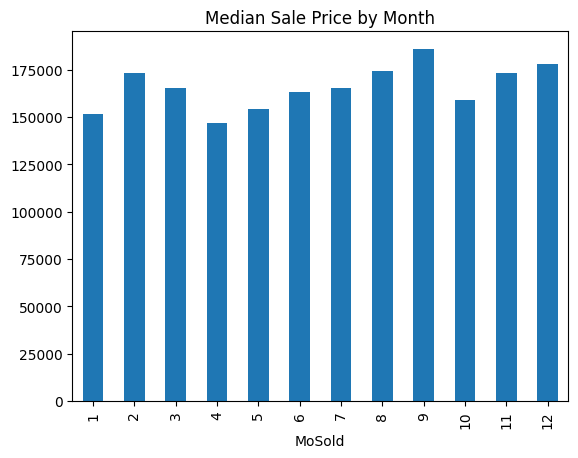

In [18]:
pd_train.groupby('MoSold')['SalePrice'].median().plot(kind='bar')
plt.title('Median Sale Price by Month')
plt.show()

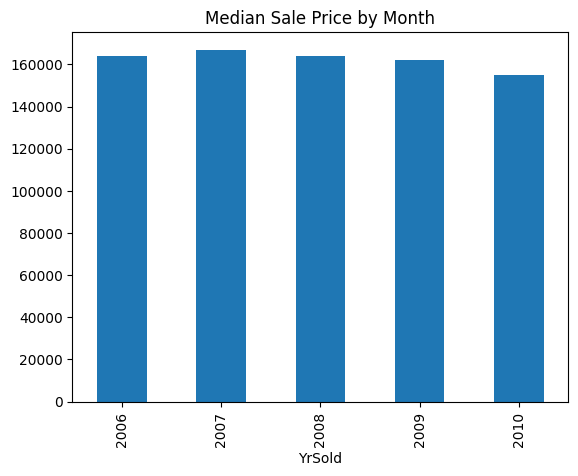

In [19]:
pd_train.groupby('YrSold')['SalePrice'].median().plot(kind='bar')
plt.title('Median Sale Price by Month')
plt.show()

In [20]:
pd_train.drop(['MoSold','YrSold'],axis=1)
pd_train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,...,0,0,0,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,...,0,0,0,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,...,0,0,0,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,...,0,0,0,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,...,0,0,0,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Reg,Lvl,Inside,Gtl,Gilbert,...,0,0,0,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Reg,Lvl,Inside,Gtl,NWAmes,...,0,0,0,MnPrv,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Reg,Lvl,Inside,Gtl,Crawfor,...,0,0,0,GdPrv,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Reg,Lvl,Inside,Gtl,NAmes,...,0,0,0,NaN,0,4,2010,WD,Normal,142125


Text(0.5, 1.0, 'Median Sale Price by Neighborhood')

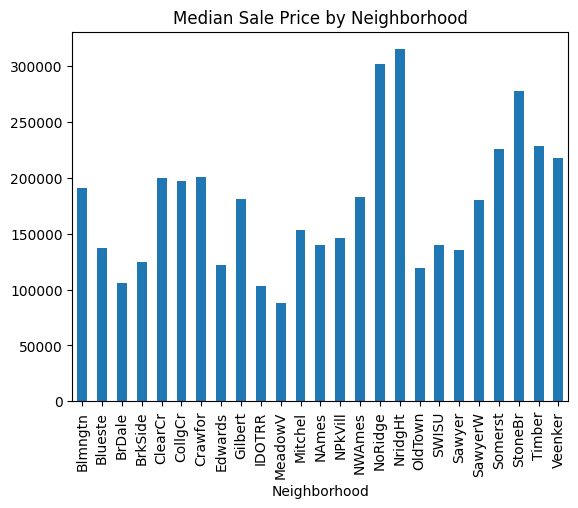

In [21]:
pd_train.groupby('Neighborhood')['SalePrice'].median().plot(kind='bar')
plt.title('Median Sale Price by Neighborhood')

In [22]:
pd_train['LotFrontage'] = pd_train.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
pd_train['LotFrontage']

,LotFrontage
0,65.0
1,80.0
2,68.0
3,60.0
4,84.0
...,...
1455,62.0
1456,85.0
1457,66.0
1458,68.0


In [23]:
print(pd_train['LotFrontage'].isna().sum())

0


Text(0.5, 1.0, 'Median Sale Price by Neighborhood')

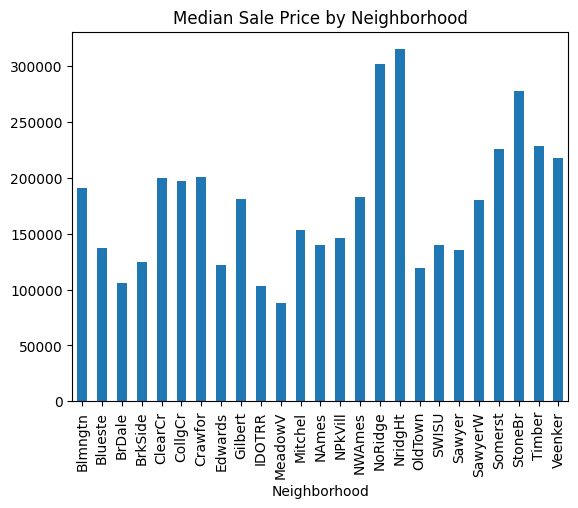

In [24]:
pd_train.groupby('Neighborhood')['SalePrice'].median().plot(kind='bar')
plt.title('Median Sale Price by Neighborhood')

In [25]:
pd_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,...,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,...,0,0,0,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,...,0,0,0,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,...,0,0,0,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,...,0,0,0,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,...,0,0,0,NaN,0,12,2008,WD,Normal,250000


In [26]:
mapping_fence={'None':0,'NA':1,'MnWw':2,'GdWo':3,'MnPrv':4,'GdPrv':5}
pd_train['Fence']=pd_train['Fence'].fillna('None').map(mapping_fence)
pd_train['Fence']

,Fence
0,0
1,0
2,0
3,0
4,0
...,...
1455,0
1456,4
1457,5
1458,0


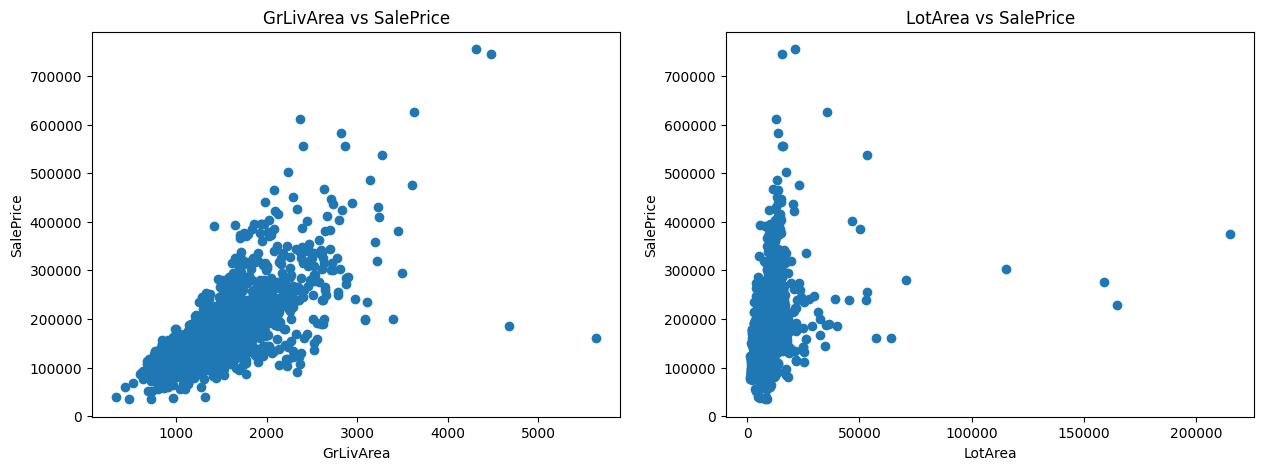

In [27]:
fig1,axes1=plt.subplots(1,2,figsize=(15,5))
axes1[0].scatter(pd_train['GrLivArea'],pd_train['SalePrice'])
axes1[0].set_xlabel('GrLivArea')
axes1[0].set_ylabel('SalePrice')
axes1[0].set_title('GrLivArea vs SalePrice')
axes1[1].scatter(pd_train['LotArea'],pd_train['SalePrice'])
axes1[1].set_xlabel('LotArea')
axes1[1].set_ylabel('SalePrice')
axes1[1].set_title('LotArea vs SalePrice')
plt.show()

In [28]:
#finding suspicious points
print(pd_train[pd_train['GrLivArea']>4000][['GrLivArea','SalePrice','SaleCondition']])
print(f"\n\n\n\n")
print(pd_train[pd_train['LotArea']>100000][['LotArea','SalePrice','SaleCondition']])

      GrLivArea  SalePrice SaleCondition
523        4676     184750       Partial
691        4316     755000        Normal
1182       4476     745000       Abnorml
1298       5642     160000       Partial





     LotArea  SalePrice SaleCondition
249   159000     277000        Normal
313   215245     375000        Normal
335   164660     228950        Normal
706   115149     302000        Normal


In [29]:
# pd_train=pd_train.drop(pd_train[(pd_train['GrLivArea']>4000) & (pd_train['SalePrice']<300000)].index)
# print(pd_train[pd_train['GrLivArea']>4000][['GrLivArea','SalePrice','SaleCondition']])

pd_train=pd_train.drop(pd_train[(pd_train['LotArea']>100000) & (pd_train['SalePrice']<400000)].index)
print(pd_train[pd_train['LotArea']>100000][['GrLivArea','SalePrice','SaleCondition']])
# pd_train=pd_train.drop(pd_train['LotArea']>100000 & pd_train['SalePrice']<300000)

Empty DataFrame
Columns: [GrLivArea, SalePrice, SaleCondition]
Index: []


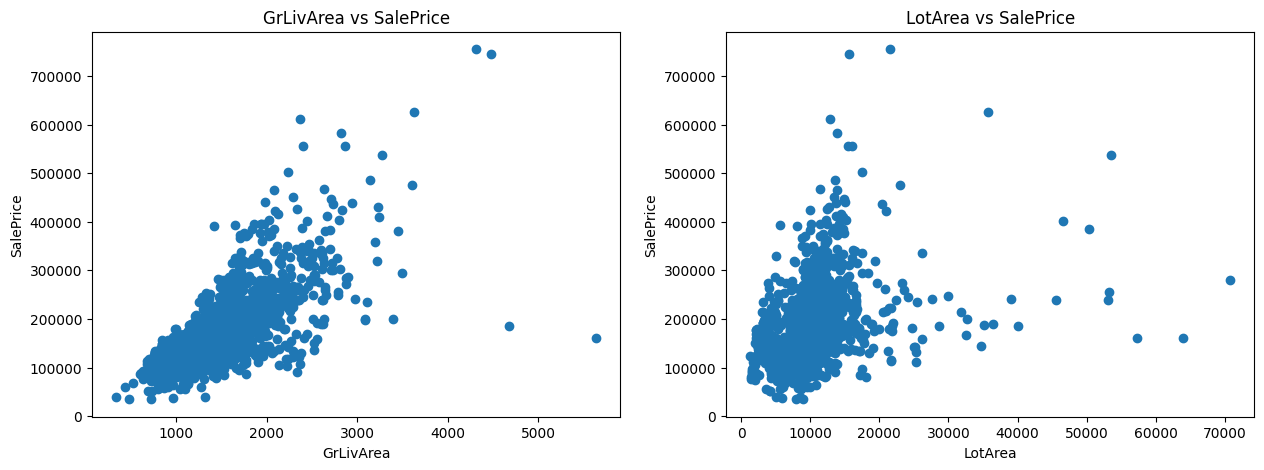

In [30]:
fig1,axes1=plt.subplots(1,2,figsize=(15,5))
axes1[0].scatter(pd_train['GrLivArea'],pd_train['SalePrice'])
axes1[0].set_xlabel('GrLivArea')
axes1[0].set_ylabel('SalePrice')
axes1[0].set_title('GrLivArea vs SalePrice')
axes1[1].scatter(pd_train['LotArea'],pd_train['SalePrice'])
axes1[1].set_xlabel('LotArea')
axes1[1].set_ylabel('SalePrice')
axes1[1].set_title('LotArea vs SalePrice')
plt.show()

In [2]:
import pandas as pd
import numpy as np

def preprocess(train_path, test_path=None):
    """
    Preprocess train (and optionally test) data for house price prediction.
    All statistics are learned from train data only — no leakage.
    """

    # ========================================
    # STEP 0: Load and keep originals safe
    # ========================================
    train = pd.read_csv(train_path).copy()
    test = pd.read_csv(test_path).copy() if test_path else None

    # Save target and IDs
    y_train = train['SalePrice']
    train_id = train['Id']
    test_id = test['Id'] if test is not None else None

    train.drop(['Id', 'SalePrice'], axis=1, inplace=True)
    if test is not None:
        test.drop(['Id'], axis=1, inplace=True)

    # ========================================
    # STEP 1: Drop useless columns
    # ========================================
    drop_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Utilities',
                 'Street', 'MoSold', 'YrSold']

    train.drop(columns=drop_cols, inplace=True)
    if test is not None:
        test.drop(columns=drop_cols, inplace=True)

    # ========================================
    # STEP 2: Remove outliers (TRAIN ONLY!)
    # ========================================
    # ⚠️ Never remove rows from test data
    outlier_mask = (train['GrLivArea'] > 4000) & (y_train < 300000)
    train = train[~outlier_mask]
    y_train = y_train[~outlier_mask]

    print(f"Removed {outlier_mask.sum()} outliers from train")

    # ========================================
    # STEP 3: LotFrontage imputation
    # ========================================
    # ⚠️ Learn medians from TRAIN, apply to BOTH
    lot_medians = train.groupby('Neighborhood')['LotFrontage'].median()

    train['LotFrontage'] = train.apply(
        lambda row: lot_medians.get(row['Neighborhood'], lot_medians.median())
        if pd.isna(row['LotFrontage']) else row['LotFrontage'], axis=1)

    if test is not None:
        test['LotFrontage'] = test.apply(
            lambda row: lot_medians.get(row['Neighborhood'], lot_medians.median())
            if pd.isna(row['LotFrontage']) else row['LotFrontage'], axis=1)

    # ========================================
    # STEP 4: Fill "Not Applicable" NaNs
    # ========================================
    # These columns: NaN means the feature doesn't exist
    none_fill_cols = [
        'FireplaceQu', 'Fence',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'GarageType', 'GarageQual', 'GarageCond', 'GarageFinish',
        'MasVnrType'
    ]

    for col in none_fill_cols:
        if col in train.columns:
            train[col] = train[col].fillna('None')
            if test is not None and col in test.columns:
                test[col] = test[col].fillna('None')

    # Numerical columns where NaN means "none" → fill with 0
    zero_fill_cols = ['MasVnrArea', 'GarageYrBlt', 'GarageArea', 'GarageCars',
                      'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                      'BsmtFullBath', 'BsmtHalfBath']

    for col in zero_fill_cols:
        if col in train.columns:
            train[col] = train[col].fillna(0)
            if test is not None and col in test.columns:
                test[col] = test[col].fillna(0)

    # ========================================
    # STEP 5: Ordinal encoding
    # ========================================

    # Group 1: Standard quality scale
    qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                 'HeatingQC', 'KitchenQual', 'FireplaceQu',
                 'GarageQual', 'GarageCond']

    # Group 2: Custom ordinal scales
    custom_maps = {
        'BsmtExposure':  {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4},
        'BsmtFinType1':  {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
        'BsmtFinType2':  {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6},
        'GarageFinish':  {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3},
        'Fence':         {'None': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4},
        'Functional':    {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8},
        'LandSlope':     {'Sev': 0, 'Mod': 1, 'Gtl': 2},
        'LotShape':      {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
        'PavedDrive':    {'N': 0, 'P': 1, 'Y': 2},
        'CentralAir':    {'N': 0, 'Y': 1},
    }

    # Apply standard quality map
    for col in qual_cols:
        if col in train.columns:
            train[col] = train[col].fillna('None').map(qual_map)
            if test is not None and col in test.columns:
                test[col] = test[col].fillna('None').map(qual_map)

    # Apply custom maps
    for col, mapping in custom_maps.items():
        if col in train.columns:
            train[col] = train[col].fillna('None').map(mapping)
            if test is not None and col in test.columns:
                test[col] = test[col].fillna('None').map(mapping)

    # ========================================
    # STEP 6: One-hot encode nominal columns
    # ========================================
    nominal_cols = train.select_dtypes(include='object').columns.tolist()

    if test is not None:
        # ⚠️ Combine before encoding so both get the same columns
        train['_is_train'] = 1
        test['_is_train'] = 0
        combined = pd.concat([train, test], axis=0, ignore_index=True)

        # Fill any remaining NaN in nominal columns with mode from TRAIN
        for col in nominal_cols:
            if combined[col].isna().any():
                train_mode = train[col].mode()[0]
                combined[col] = combined[col].fillna(train_mode)

        combined = pd.get_dummies(combined, columns=nominal_cols, drop_first=True)

        # Split back
        train = combined[combined['_is_train'] == 1].drop('_is_train', axis=1)
        test = combined[combined['_is_train'] == 0].drop('_is_train', axis=1)
    else:
        for col in nominal_cols:
            if train[col].isna().any():
                train[col] = train[col].fillna(train[col].mode()[0])
        train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)

    # ========================================
    # STEP 7: Fill any remaining NaN
    # ========================================
    # ⚠️ Use train median for both
    train_medians = train.median()
    train = train.fillna(train_medians)
    if test is not None:
        test = test.fillna(train_medians)

    #feature modifier
    def add_features(df):
        df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
        df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
        df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
        return df

    #========================================
    # STEP 8: Implement feature engineering
    #========================================
    train = add_features(train)
    if test is not None:
          test = add_features(test)



    # ========================================
    # VALIDATION
    # ========================================
    print(f"\nTrain shape: {train.shape}")
    print(f"Train NaN remaining: {train.isna().sum().sum()}")
    print(f"Target shape: {y_train.shape}")

    if test is not None:
        print(f"Test shape: {test.shape}")
        print(f"Test NaN remaining: {test.isna().sum().sum()}")
        return train, y_train, test, train_id, test_id

    return train, y_train, train_id


# ========================================
# RUN IT
# ========================================
if __name__ == "__main__":
    # Fix: Call with train.csv as train_path and test.csv as test_path
    result = preprocess("/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv", "/content/drive/MyDrive/house-prices-advanced-regression-techniques/test.csv")

Removed 2 outliers from train

Train shape: (1458, 193)
Train NaN remaining: 0
Target shape: (1458,)
Test shape: (1459, 193)
Test NaN remaining: 0


/tmp/ipykernel_1669/2982112903.py:165: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
/tmp/ipykernel_1669/2982112903.py:166: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TotalBath'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
/tmp/ipykernel_1669/2982112903.py:167: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

In [3]:
result

(      MSSubClass  LotFrontage  LotArea  LotShape  LandSlope  OverallQual  \
 0             60         65.0     8450         3          2            7   
 1             20         80.0     9600         3          2            6   
 2             60         68.0    11250         2          2            7   
 3             70         60.0     9550         2          2            7   
 4             60         84.0    14260         2          2            8   
 ...          ...          ...      ...       ...        ...          ...   
 1453          60         62.0     7917         3          2            6   
 1454          20         85.0    13175         3          2            6   
 1455          70         66.0     9042         3          2            7   
 1456          20         68.0     9717         3          2            5   
 1457          20         75.0     9937         3          2            5   
 
       OverallCond  YearBuilt  YearRemodAdd  MasVnrArea  ...  SaleType_Oth

In [11]:
X, y, X_test, train_ids, test_ids = result

In [12]:
#Implementing random forest Algorithm
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import (GradientBoostingRegressor, RandomForestRegressor)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_log_error
print(f"Import Successful!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")


Import Successful!
XGBoost version: 3.4.1
LightGBM version: 4.6.0


In [15]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
models={
     'Random Forest': RandomForestRegressor(n_estimators=100,random_state=42),
     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100,random_state=42),
     'XGBoost': xgb.XGBRegressor(n_estimators=100,random_state=42),
     'LightGBM': lgb.LGBMRegressor(n_estimators=100,random_state=42)
 }
model_details=[]
kf=KFold(n_splits=5,shuffle=True,random_state=42)

for model_name, model in models.items():
    rmse=-cross_val_score(model,X_train,y_train,scoring='neg_root_mean_squared_error',cv=kf)
    mae=-cross_val_score(model,X_train,y_train,scoring='neg_mean_absolute_error',cv=kf)
    r2_score=-cross_val_score(model,X_train,y_train,scoring='r2',cv=kf)

    print(f"\n{model_name}")
    print(f"RMSE: ${rmse.mean():,.0f}(+/-${rmse.std():,.0f})")
    print(f"MAE: ${mae.mean():,.0f}(+/-${mae.std():,.0f})")
    print(f"R2: ${r2_score.mean():,.0f}(+/-${r2_score.std():,.0f})")
    model_details.append({
        'Model': model_name,
        'RMSE': rmse.mean(),
        'MAE': mae.mean(),
        'R2': r2_score.mean()
    })

#print the details of the model with the minimum values
min_rmse_model = min(model_details, key=lambda x: x['RMSE'])
print(f"\nModel with minimum RMSE: {min_rmse_model['Model']}")



Random Forest
RMSE: $27,129(+/-$2,265)
MAE: $17,165(+/-$2,180)
R2: $-1(+/-$0)

Gradient Boosting
RMSE: $24,501(+/-$2,642)
MAE: $15,730(+/-$1,911)
R2: $-1(+/-$0)

XGBoost
RMSE: $28,601(+/-$2,964)
MAE: $17,859(+/-$1,826)
R2: $-1(+/-$0)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000849 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3278
[LightGBM] [Info] Number of data points in the train set: 932, number of used features: 120
[LightGBM] [Info] Start training from score 177561.810086
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000882 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you 

In [16]:
best_model=xgb.XGBRegressor(n_estimators=100,random_state=42)
best_model.fit(X_train,y_train)
test_predictions=best_model.predict(X_test)


In [17]:
print(test_predictions)

[123363.37 171696.97 190427.48 ... 152007.89 119657.26 215826.38]


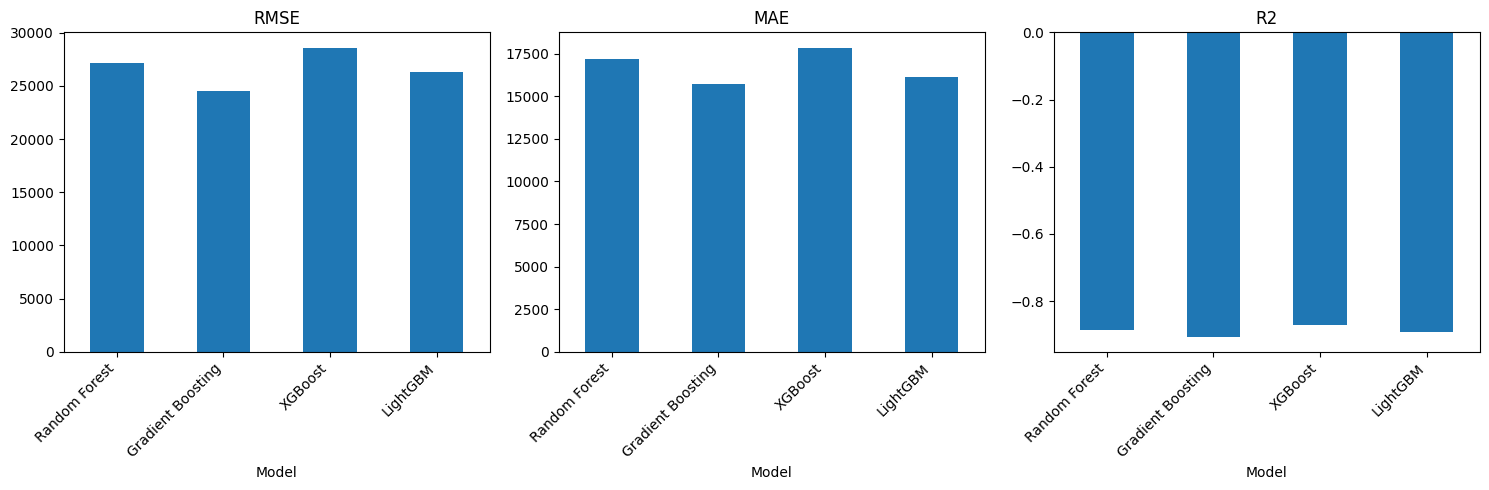

In [20]:
#showing the results in the form of the graph
details_df=pd.DataFrame(model_details)
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize=(15,5))
metrics=['RMSE','MAE','R2']
for ax,metric in zip(axes, metrics):
  details_df.plot.bar(x='Model', y=metric, ax=ax, legend=False)
  ax.set_title(metric)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


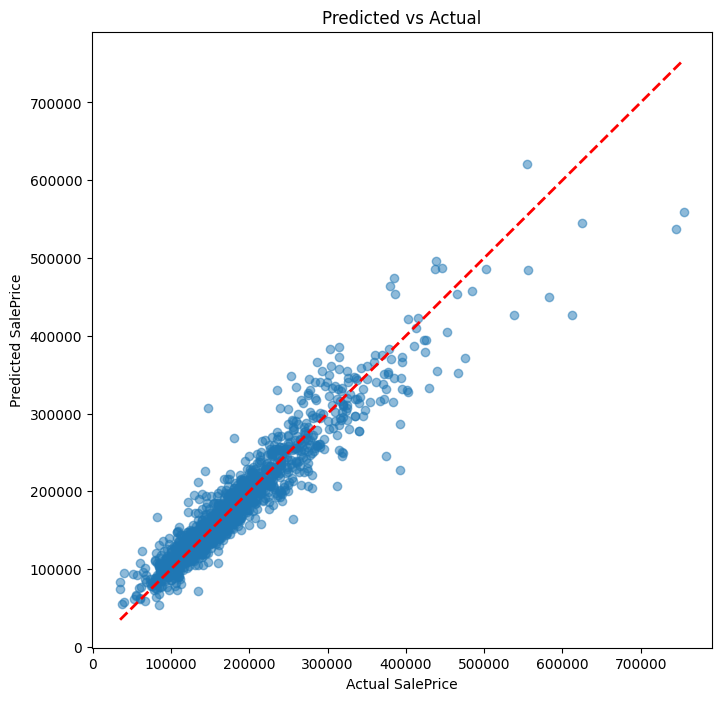

In [21]:
from sklearn.model_selection import cross_val_predict

# Get predictions using cross-validation
y_pred = cross_val_predict(best_model, X, y, cv=kf)

plt.figure(figsize=(8, 8))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)  # perfect prediction line
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Predicted vs Actual')
plt.show()

In [22]:
#Create the new data frames of predicted, actual and difference
table_1=pd.DataFrame({'Actual':y,'Predicted':y_pred})
table_1['Difference']=table_1['Actual']-table_1['Predicted']

In [23]:
table_1.head(10)

,Actual,Predicted,Difference
0,208500,204110.000000,4390.000000
1,181500,168303.453125,13196.546875
2,223500,209155.515625,14344.484375
3,140000,196386.562500,-56386.562500
4,250000,272396.843750,-22396.843750
5,143000,167169.015625,-24169.015625
6,307000,281370.031250,25629.968750
7,200000,245348.640625,-45348.640625
8,129900,135733.453125,-5833.453125
9,118000,131096.468750,-13096.468750


In [24]:
#convert dataframes into csv
table_1.to_csv('table_1.csv',index=False)